In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.cluster import SpectralClustering
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from PIL import Image
import requests
from tqdm import tqdm
from io import BytesIO

%matplotlib inline
# Suppress specific warning from GWpy
warnings.filterwarnings('ignore', message="Wswiglal-redir-stdio")
warnings.filterwarnings('ignore')

# Plot format 
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.25,
    'lines.linewidth': 1.2,
})


In [ ]:
# Functions
def reorder_clusters(true_labels, cluster_labels):
    "Reorder cluster labels to maximize alignment with true labels"
    # Confusion matrix
    cm = confusion_matrix(true_labels, cluster_labels)
    
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    # Mapping from old cluster to new cluster
    mapping = {old: new for new, old in enumerate(col_ind)}
    
    # Reorder cluster labels
    reordered_labels = np.array([mapping[label] for label in cluster_labels])
    
    return reordered_labels, cm, mapping

def download_and_save_cropped(df, folder="glitch_images_cropped_new"):
    "Download, crop, and save all images locally"
    CROP_X = [66, 532]
    CROP_Y = [105, 671]
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Saving cropped images"):
        for i, url in enumerate([row['url1'], row['url3']]):
            filename = f"{folder}/{row.name}_{i}.png"
            if not os.path.exists(filename):
                response = requests.get(url)
                img = Image.open(BytesIO(response.content))
                img_array = np.array(img)
                cropped = img_array[CROP_X[0]:CROP_X[1], CROP_Y[0]:CROP_Y[1], :3]
                Image.fromarray(cropped).save(filename)


Text(0, 0.5, 'Frequency')

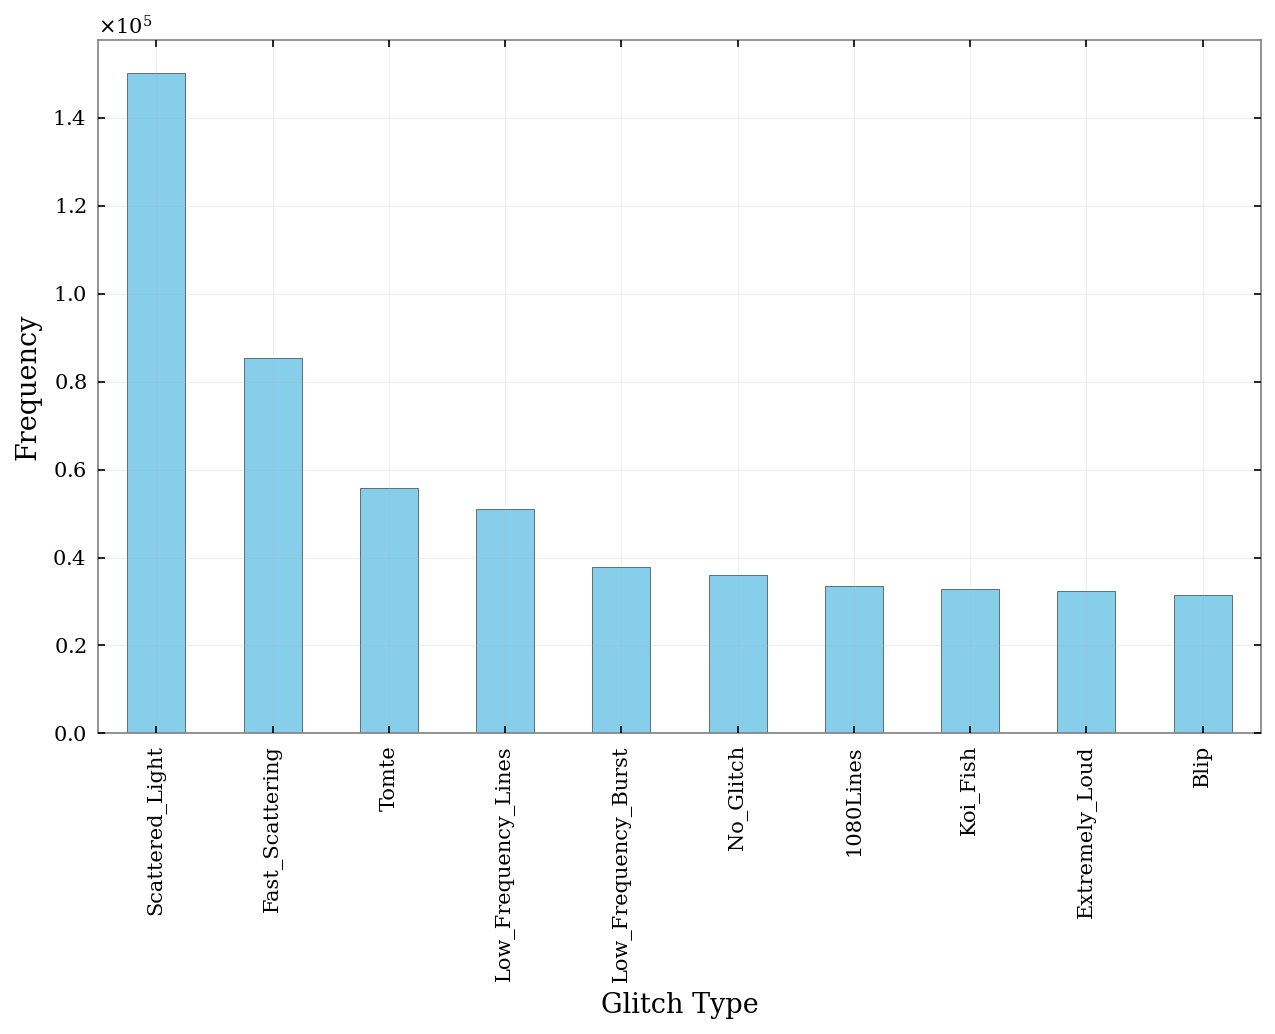

In [85]:
# Load dataset
files = {
    "L1_O2": "L1_O2.csv",
    "L1_O3b": "L1_O3b.csv",
    "L1_O3a": "L1_O3a.csv",    
    "H1_O2": "H1_O2.csv",
    "H1_O3b": "H1_O3b.csv",
    "H1_O3a": "H1_O3a.csv",
}

dfs = []

for file_name in files.keys():
    df = pd.read_csv(file_name + ".csv")
    dfs.append(df)

glitches = pd.concat(dfs, ignore_index=True)
glitches.head()

# Top 10 most common glitch class labels
top_10_labels = glitches['ml_label'].value_counts().head(10).index.tolist()

# Filter the dataframe
top_10_glitches = glitches[glitches['ml_label'].isin(top_10_labels)].copy()
glitches = top_10_glitches.copy()

# Plot histogram
plt.figure(figsize=(10, 6))
glitches['ml_label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Glitch Type')
plt.ylabel('Frequency')


In [ ]:
# Download and crop images from dataset 

# Save cropped images locally
# os.makedirs("glitch_images_cropped_new", exist_ok=True)

# Rows with invalid URLs
# invalid_urls = []
# for idx, row in remaining_glitches.iterrows():
#     if not isinstance(row['url1'], str) or len(row['url1']) < 10 or row['url1'] == '?':
#         invalid_urls.append(idx)
#         print(f"Invalid URL at index {idx}: {row['url1']}")

# print(f"Found {len(invalid_urls)} invalid entries")

# Filter 
# clean_glitches = remaining_glitches.drop(index=invalid_urls)
# print(f"Clean glitches: {len(clean_glitches)}")

# download_and_save_cropped(clean_glitches.sample(min(2000, len(clean_glitches)), random_state=42))

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, 3, stride=2, padding=1),    # -> (32,64,64)
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),   # -> (64,32,32)
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # -> (128,16,16)
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu     = nn.Linear(128*16*16, latent_dim)
        self.fc_logvar = nn.Linear(128*16*16, latent_dim)
        self.fc = nn.Linear(latent_dim, 128*16*16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # -> (64,32,32)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # -> (32,64,64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 2, 4, stride=2, padding=1),    # -> (2,128,128)
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc(z)
        h = h.view(-1, 128, 16, 16)
        return self.decoder(h)

    def forward(self, x, kl_weight=0.1):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)

        # Loss
        recon_loss = F.mse_loss(x_recon, x)

        kl_loss = -0.5 * torch.mean(
            1 + logvar - mu.pow(2) - logvar.exp()
        )
         
        loss = recon_loss + kl_weight * kl_loss

        return x_recon, loss, recon_loss, kl_loss
    

In [ ]:
class GlitchDatasetFromDisk(Dataset):
    def __init__(self, df, img_folder="glitch_images_cropped_new"):
        self.df = df.reset_index(drop=True)
        self.img_folder = img_folder
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
        ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['img_id']
        imgs = []
        for i in range(2):
            filename = f"{self.img_folder}/{img_id}_{i}.png"
            img = Image.open(filename)
            img = self.transform(img)
            imgs.append(img)
        return torch.cat(imgs, dim=0)

class GlitchDatasetWithLabels(Dataset):
    def __init__(self, df, img_folder="glitch_images_cropped_new"):
        self.df = df.reset_index(drop=True)
        self.img_folder = img_folder
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
        ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['img_id']
        
        imgs = []
        for i in range(2):
            filename = f"{self.img_folder}/{img_id}_{i}.png"
            img = Image.open(filename)
            img = self.transform(img)
            imgs.append(img)
        
        return torch.cat(imgs, dim=0), row['ml_label']


In [ ]:
files = os.listdir("glitch_images_cropped_new")

ids = []
for f in files:
    if f.endswith("_0.png"):
        img_id = int(f.split("_")[0])
        ids.append(img_id)

valid_ids = list(set(ids) & set(glitches.index))  # Intersection of both sets
print(f"Valid IDs after filtering: {len(valid_ids)}")

glitches_small = glitches.loc[valid_ids].copy()

# original indices
glitches_small["img_id"] = glitches_small.index
glitches_small = glitches_small.sample(frac=1, random_state=42).reset_index(drop=True)
train_val, test = train_test_split(
    glitches_small,
    test_size=0.1,
    random_state=42
)

train, val = train_test_split(
    train_val,
    test_size=0.2/0.9,
    random_state=42
)

# All indices that have both views
cropped_files = os.listdir("glitch_images_cropped_new")

valid_ids = set()
for f in cropped_files:
    if f.endswith("_0.png"):
        img_id = int(f.split("_")[0])
        # Check if _1.png exists
        if f"{img_id}_1.png" in cropped_files:
            valid_ids.add(img_id)


remaining_glitches = glitches.drop(index=valid_ids, errors='ignore')

print(f"Total glitches: {len(glitches_small)}")

Valid IDs after filtering: 14136
Total glitches: 14136


In [9]:
train_filtered = train[train['img_id'].isin(valid_ids)]
val_filtered = val[val['img_id'].isin(valid_ids)]
test_filtered = test[test['img_id'].isin(valid_ids)]

train_dataset = GlitchDatasetFromDisk(train_filtered, img_folder="glitch_images_cropped_new")
val_dataset = GlitchDatasetFromDisk(val_filtered, img_folder="glitch_images_cropped_new")
test_dataset = GlitchDatasetFromDisk(test_filtered, img_folder="glitch_images_cropped_new")

# loaders
val_loader = DataLoader(val_dataset, batch_size=32) 
test_loader = DataLoader(test_dataset, batch_size=32) 

print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Weights 
class_counts = train_filtered['ml_label'].value_counts()
class_weights = 1.0 / class_counts  
sample_weights = [class_weights[label] for label in train_filtered['ml_label']]

# Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Sampler in DataLoader
train_loader = DataLoader(
    train_dataset, batch_size=32, sampler=sampler, pin_memory=True)

Val batches: 89
Test batches: 45


Train Set
ml_label
Scattered_Light        2714
Fast_Scattering        1563
Tomte                  1072
Low_Frequency_Lines     895
No_Glitch               688
Low_Frequency_Burst     683
Extremely_Loud          603
1080Lines               577
Blip                    559
Koi_Fish                540
Name: count, dtype: int64
Validation Set
ml_label
Scattered_Light        782
Fast_Scattering        474
Tomte                  281
Low_Frequency_Lines    255
Low_Frequency_Burst    231
Blip                   172
No_Glitch              167
Extremely_Loud         166
Koi_Fish               161
1080Lines              139
Name: count, dtype: int64
Test Set
ml_label
Scattered_Light        348
Fast_Scattering        265
Low_Frequency_Lines    133
Tomte                  130
No_Glitch               95
Blip                    93
1080Lines               92
Koi_Fish                91
Low_Frequency_Burst     91
Extremely_Loud          76
Name: count, dtype: int64


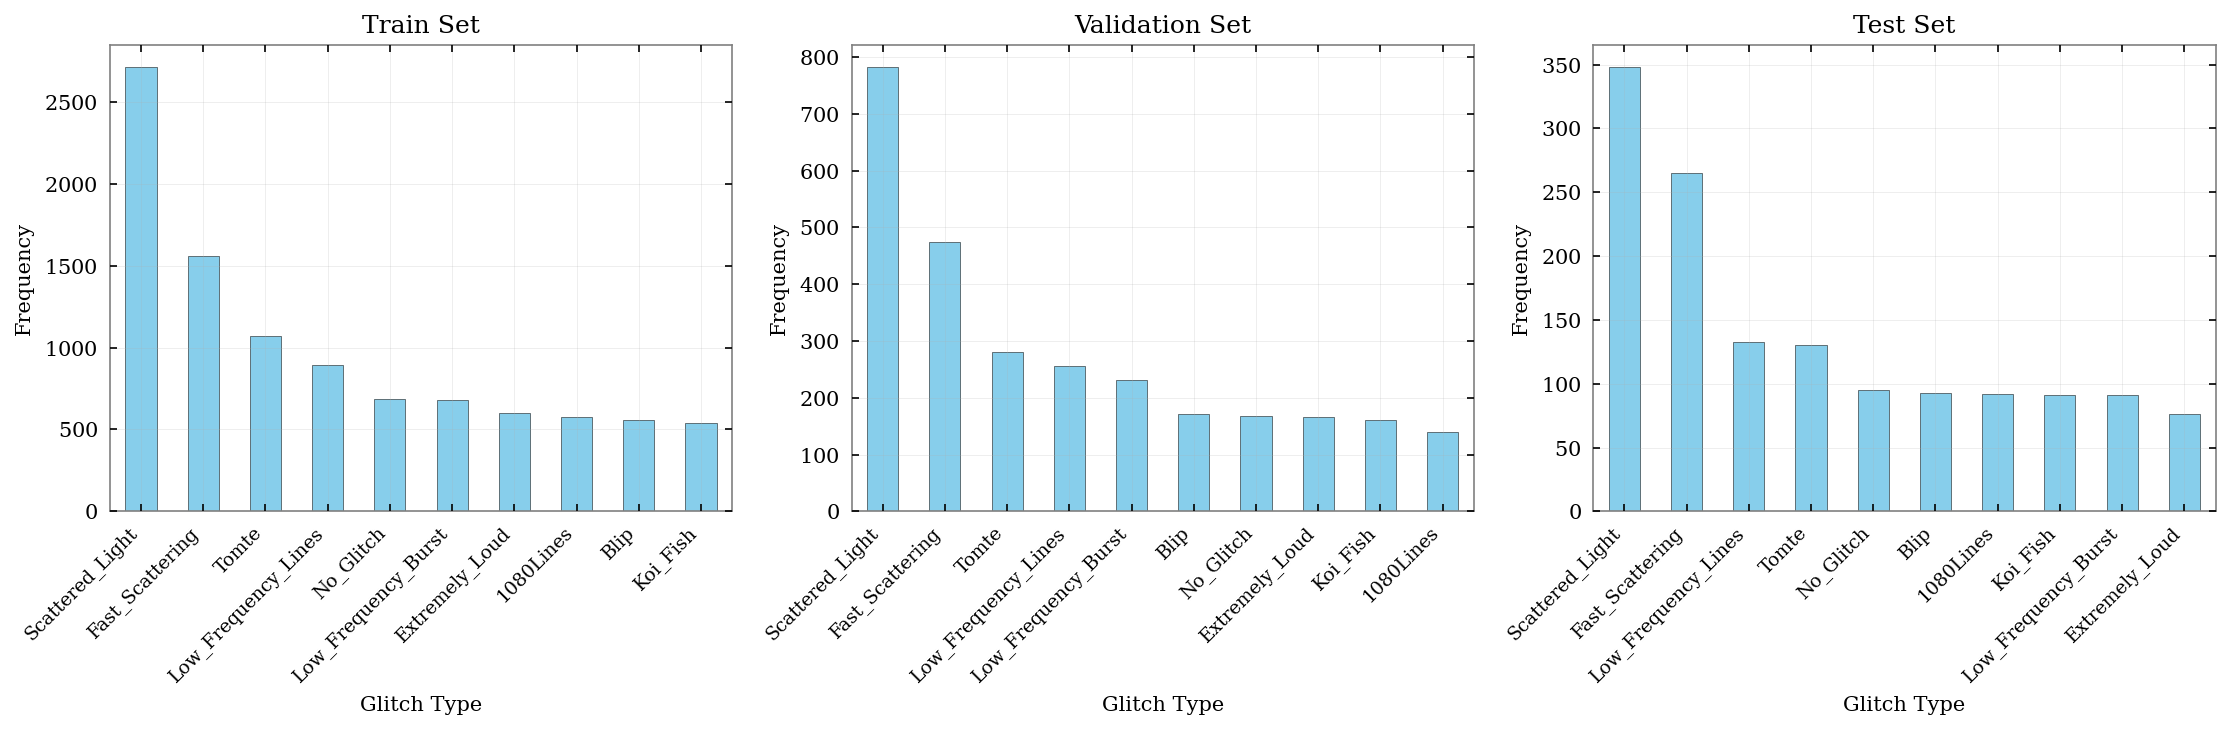

In [11]:
print("Train Set")
print(train['ml_label'].value_counts())

print("Validation Set")
print(val['ml_label'].value_counts())

print("Test Set")
print(test['ml_label'].value_counts())


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, data, title in zip(axes, [train, val, test], ['Train', 'Validation', 'Test']):
    data['ml_label'].value_counts().plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'{title} Set', fontsize=12)
    ax.set_xlabel('Glitch Type', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right')
plt.tight_layout()
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(latent_dim=128).to(device) 
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5) 

In [ ]:
# TRAIN
epochs = 20 

loss_matrix = []
train_losses = []
val_losses = []
kl_weight = 0.005      

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        x_recon, loss, recon_loss, kl_loss = model(batch, kl_weight=kl_weight)

        loss.backward()
        optimizer.step()
        loss_matrix.append((loss.item(), recon_loss.item(), kl_loss.item()))

        total_loss += loss.item()
        
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION 
    model.eval()  
    total_val_loss = 0
    latent_vectors = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            x_recon, loss, recon_loss, kl_loss = model(batch, kl_weight=kl_weight)
            total_val_loss += loss.item()
            # Encode 
            mu, logvar = model.encode(batch)

            # Move to CPU 
            latent_vectors.append(mu.cpu())
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    latent_vectors = torch.cat(latent_vectors, dim=0)
    print(latent_vectors.shape)
    print(f"Epoch {epoch+1}: kl={kl_weight:.3f}, Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}")

torch.save(model.state_dict(), "vae_final.pt")

print("Final model saved as vae_final.pt")

torch.Size([2828, 128])
Epoch 1: kl=0.005, Train=0.0177, Val=0.0089
torch.Size([2828, 128])
Epoch 2: kl=0.005, Train=0.0075, Val=0.0068
torch.Size([2828, 128])
Epoch 3: kl=0.005, Train=0.0067, Val=0.0062
torch.Size([2828, 128])
Epoch 4: kl=0.005, Train=0.0061, Val=0.0058
torch.Size([2828, 128])
Epoch 5: kl=0.005, Train=0.0059, Val=0.0055
torch.Size([2828, 128])
Epoch 6: kl=0.005, Train=0.0056, Val=0.0055
torch.Size([2828, 128])
Epoch 7: kl=0.005, Train=0.0055, Val=0.0053
torch.Size([2828, 128])
Epoch 8: kl=0.005, Train=0.0054, Val=0.0053
torch.Size([2828, 128])
Epoch 9: kl=0.005, Train=0.0053, Val=0.0051
torch.Size([2828, 128])
Epoch 10: kl=0.005, Train=0.0054, Val=0.0051
torch.Size([2828, 128])
Epoch 11: kl=0.005, Train=0.0052, Val=0.0050
torch.Size([2828, 128])
Epoch 12: kl=0.005, Train=0.0051, Val=0.0051
torch.Size([2828, 128])
Epoch 13: kl=0.005, Train=0.0052, Val=0.0050
torch.Size([2828, 128])
Epoch 14: kl=0.005, Train=0.0051, Val=0.0050
torch.Size([2828, 128])
Epoch 15: kl=0.005,

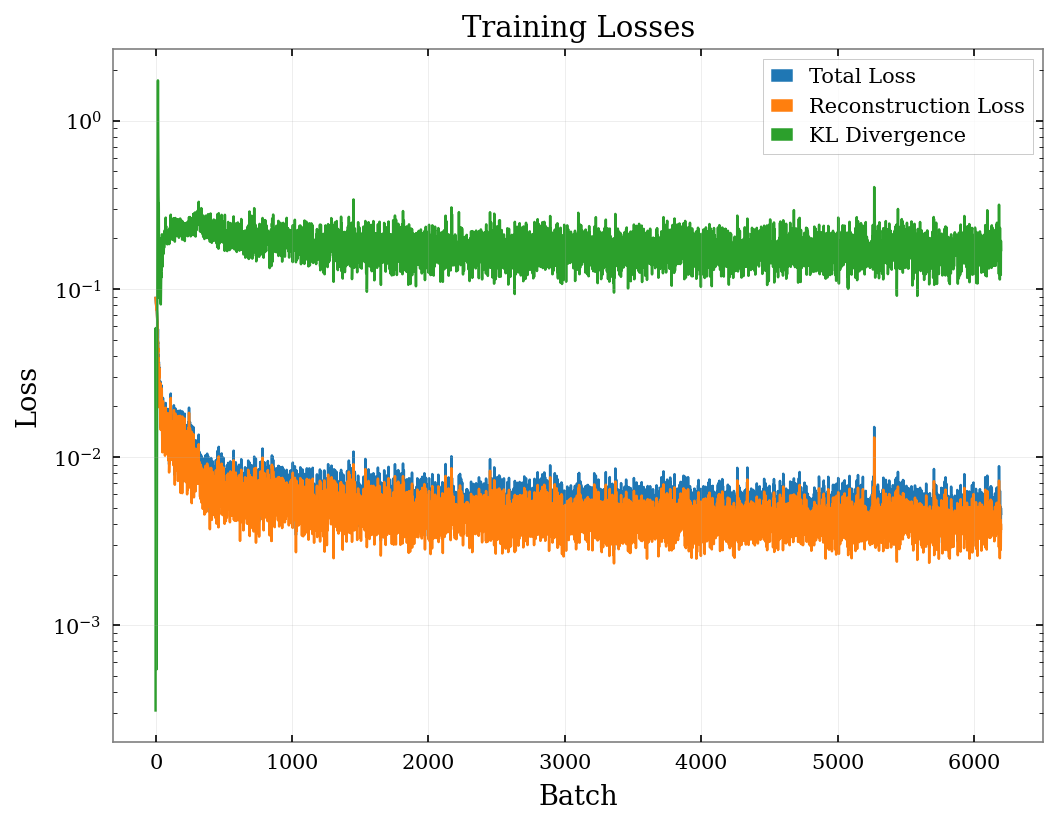

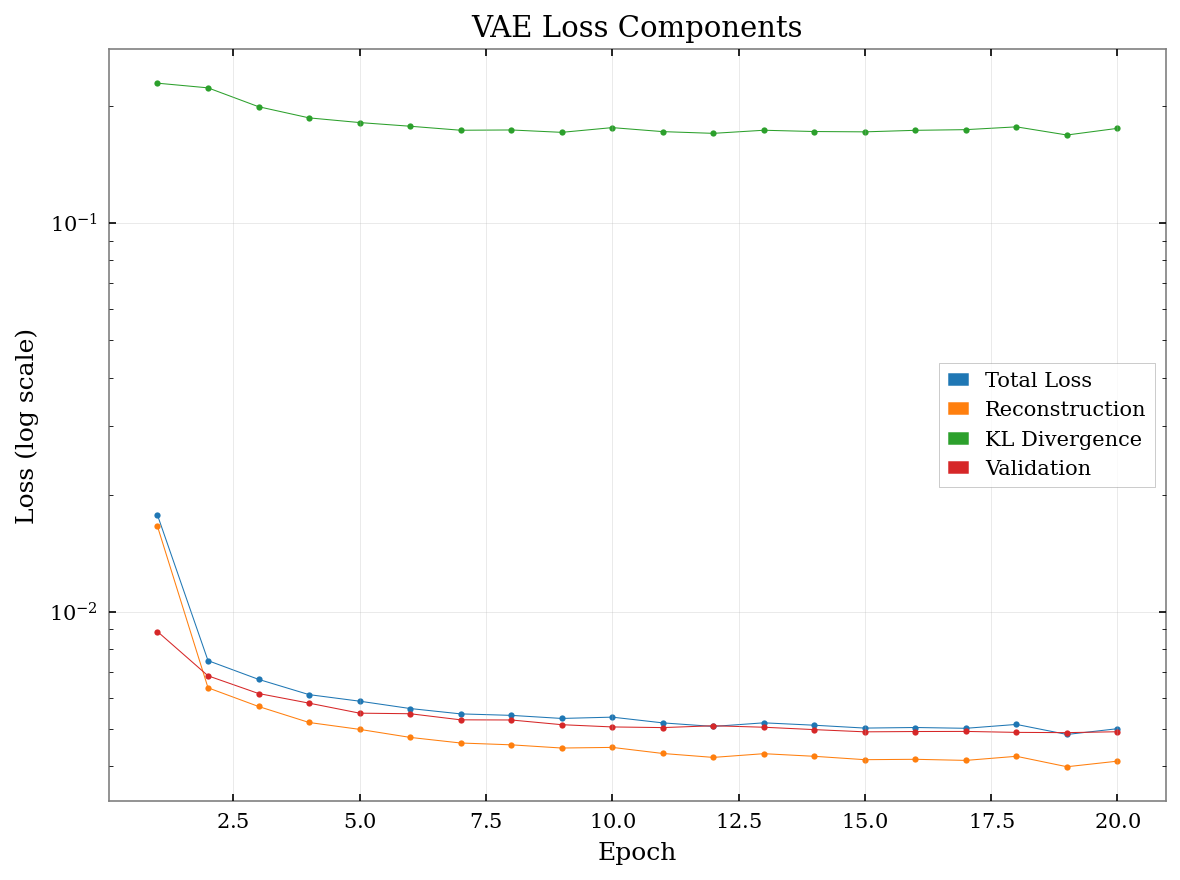

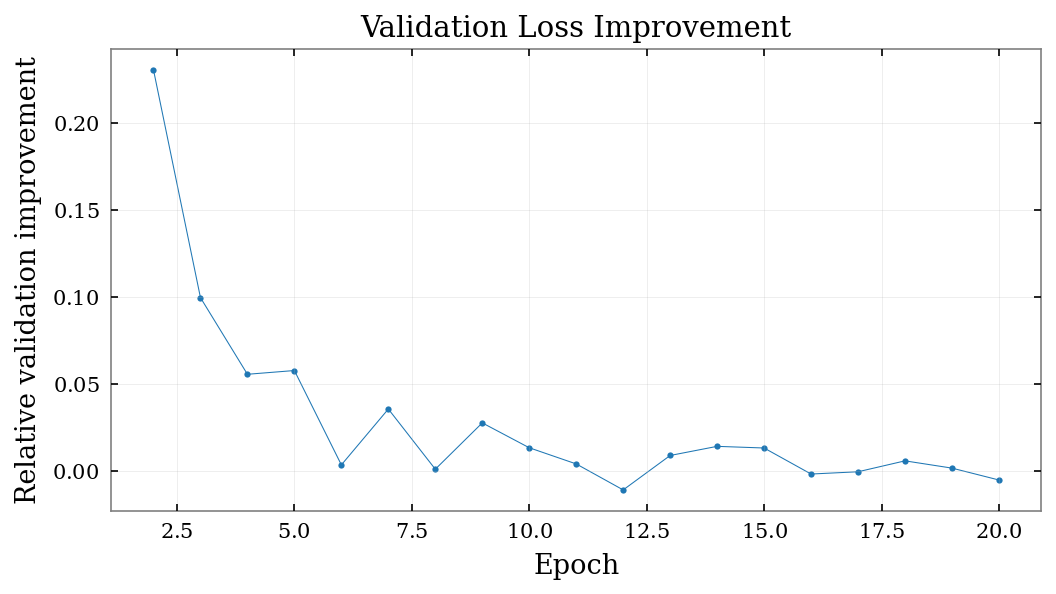

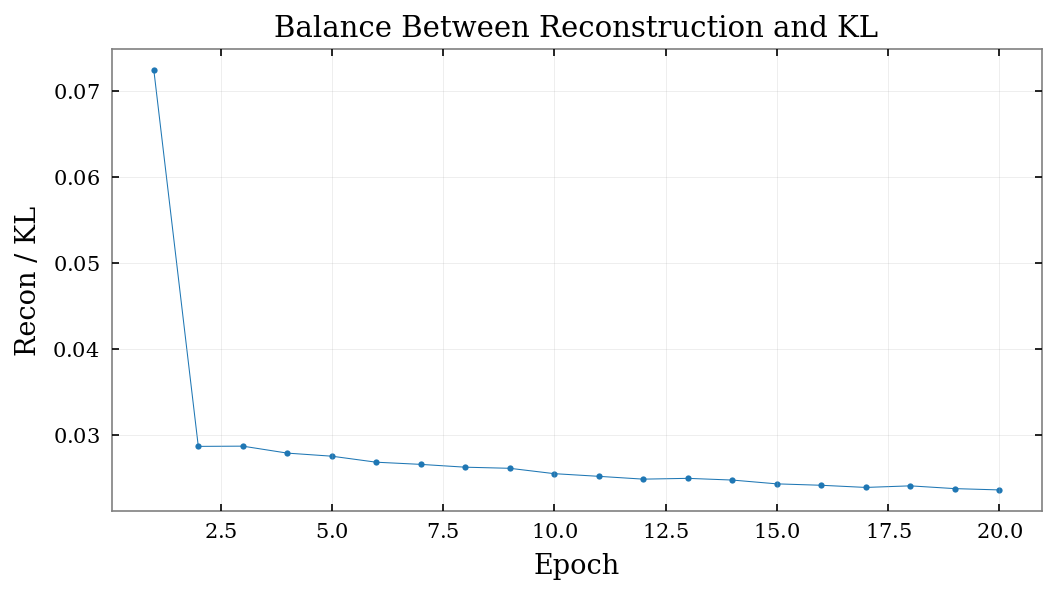

In [48]:

fig = plt.figure(figsize=(8, 6))
plt.plot(loss_matrix, label=['Total Loss', 'Reconstruction Loss', 'KL Divergence'])
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training Losses')
plt.legend()
plt.show()  


loss_matrix = np.array(loss_matrix) 
batches_per_epoch = len(train_loader)
epochs_range = range(1, epochs + 1)

# Average each component per epoch
total_per_epoch = [loss_matrix[(e-1)*batches_per_epoch : e*batches_per_epoch, 0].mean() for e in epochs_range]
recon_per_epoch = [loss_matrix[(e-1)*batches_per_epoch : e*batches_per_epoch, 1].mean() for e in epochs_range]
kl_per_epoch    = [loss_matrix[(e-1)*batches_per_epoch : e*batches_per_epoch, 2].mean() for e in epochs_range]



fig, ax = plt.subplots(figsize=(8, 6))

colors = {'total': '#1f77b4', 'recon': '#ff7f0e', 'kl': '#2ca02c', 'val': '#d62728'}
ax.plot(epochs_range, total_per_epoch, 'o-', color=colors['total'], 
        linewidth=0.5, markersize=3, label='Total Loss')
ax.plot(epochs_range, recon_per_epoch, 'o-', color=colors['recon'], 
        linewidth=0.5, markersize=3, label='Reconstruction')
ax.plot(epochs_range, kl_per_epoch, 'o-', color=colors['kl'], 
        linewidth=0.5, markersize=3, label='KL Divergence')
ax.plot(epochs_range, val_losses, 'o-', color=colors['val'], 
        linewidth=0.5, markersize=3, label='Validation')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
ax.set_title('VAE Loss Components', fontsize=14)

plt.tight_layout()
plt.show()

relative_change = []
for i in range(1, len(val_losses)):
    change = (val_losses[i-1] - val_losses[i]) / val_losses[i-1]
    relative_change.append(change)

plt.figure(figsize=(8,4))
plt.plot(range(2, epochs+1), relative_change, marker='o', linewidth=0.5, markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Relative validation improvement")
plt.title("Validation Loss Improvement")
plt.grid(True)
plt.show()

ratio = np.array(recon_per_epoch) / np.array(kl_per_epoch)

plt.figure(figsize=(8,4))
plt.plot(epochs_range, ratio, marker='o', linewidth=0.5, markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Recon / KL")
plt.title("Balance Between Reconstruction and KL")
plt.grid(True)
plt.show()

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TRAIN
model = VAE(latent_dim=128).to(device)
model.load_state_dict(torch.load("vae_final.pt", map_location=device))  
model.eval()

# Test set
total_loss = 0
latents = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        batch = batch.to(device)
        
        x_recon, loss, _, _ = model(batch, kl_weight=0.005) 
        total_loss += loss.item()
        
        mu, _ = model.encode(batch)
        latents.append(mu.cpu().numpy())
        

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{len(test_loader)} batches")

latents2 = np.vstack(latents)
avg_loss = total_loss / len(test_loader)

print(f"Test Loss: {avg_loss:.4f}")
print(f"Latents shape: {latents2.shape}")


Device: cpu
Processed 10/45 batches
Processed 20/45 batches
Processed 30/45 batches
Processed 40/45 batches
Test Loss: 0.0052
Latents shape: (1414, 128)


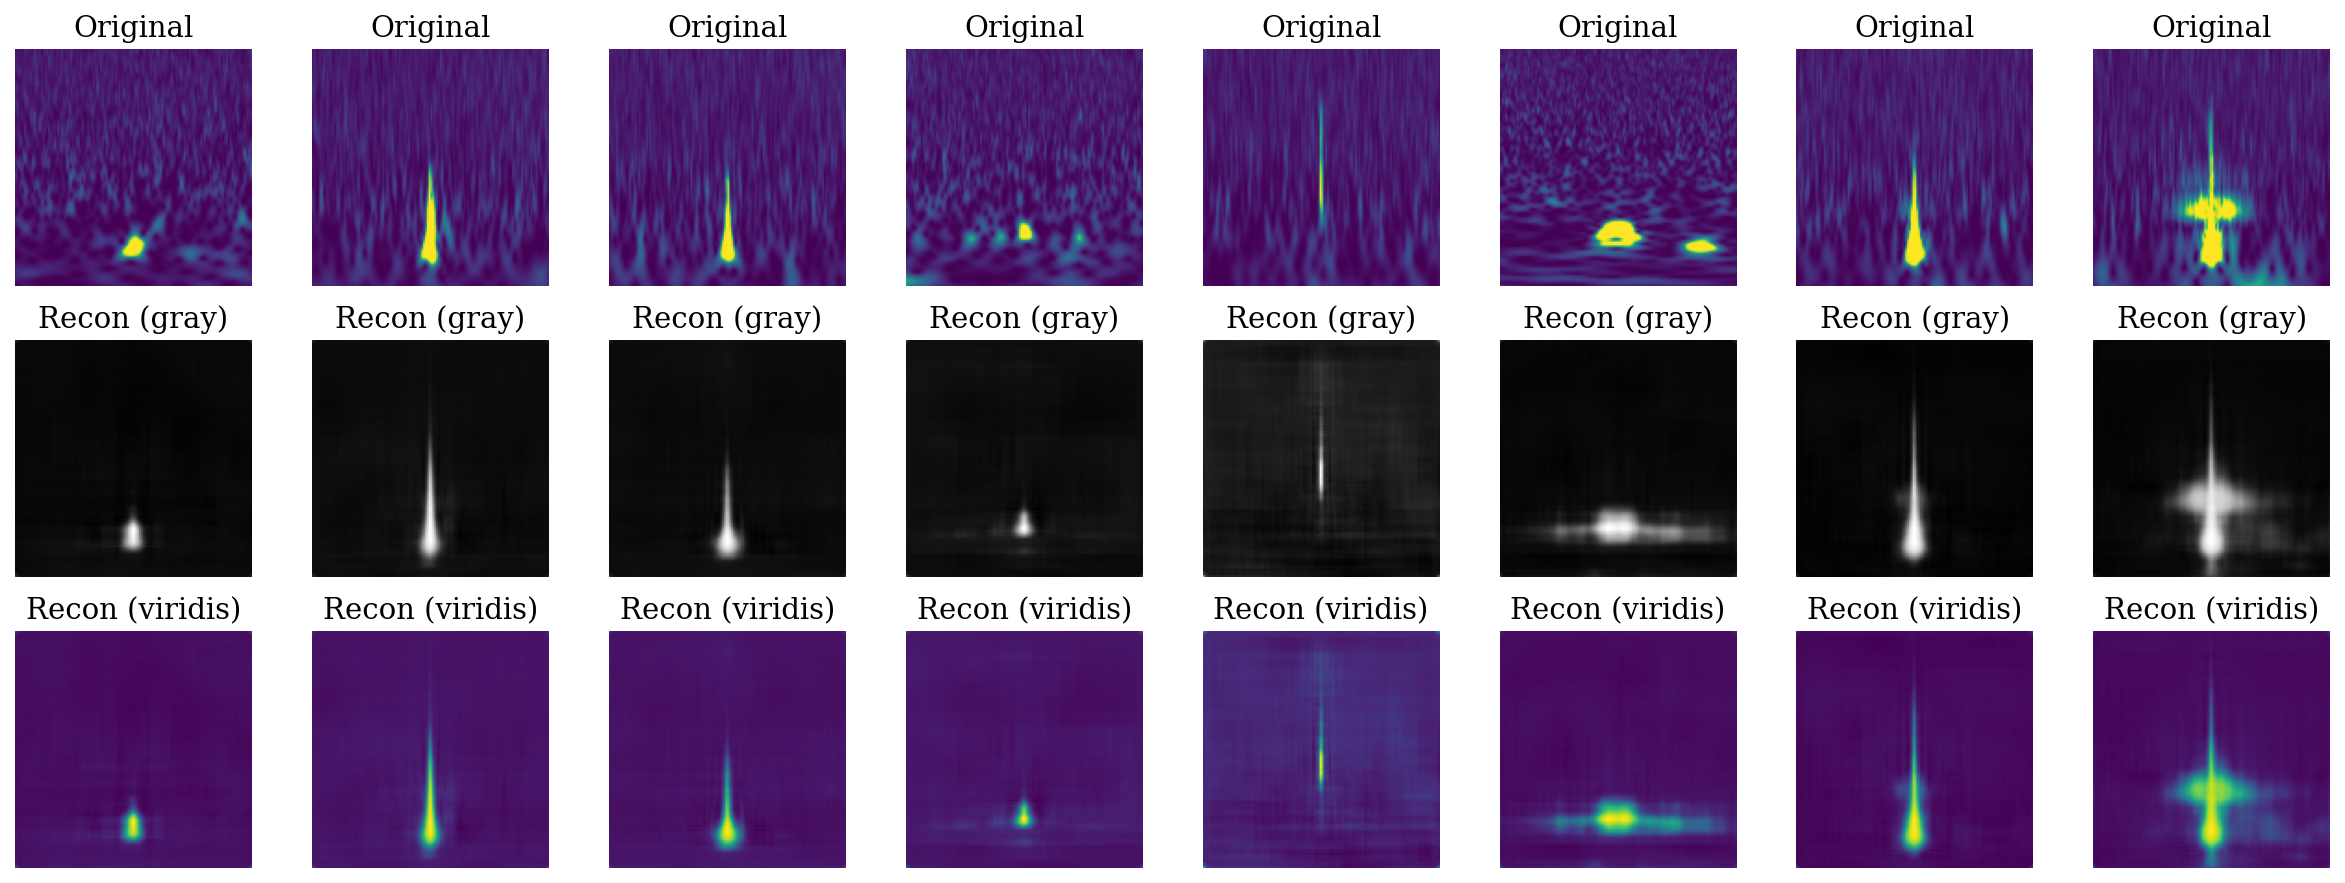

In [ ]:
# Compare both reconst images with originals
model.eval()
with torch.no_grad():
    batch = next(iter(test_loader))
    batch = batch.to(device)
    recon, _, _, _ = model(batch, kl_weight=0.005) 

fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for i in range(8):
    # Original
    axes[0, i].imshow(batch[i, 1].cpu(), cmap='viridis')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    
    # Reconstruction (gray)
    axes[1, i].imshow(recon[i, 1].cpu(), cmap='gray')
    axes[1, i].set_title('Recon (gray)')
    axes[1, i].axis('off')
    
    # Reconstruction (viridis) 
    axes[2, i].imshow(recon[i, 1].cpu(), cmap='viridis')
    axes[2, i].set_title('Recon (viridis)')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()



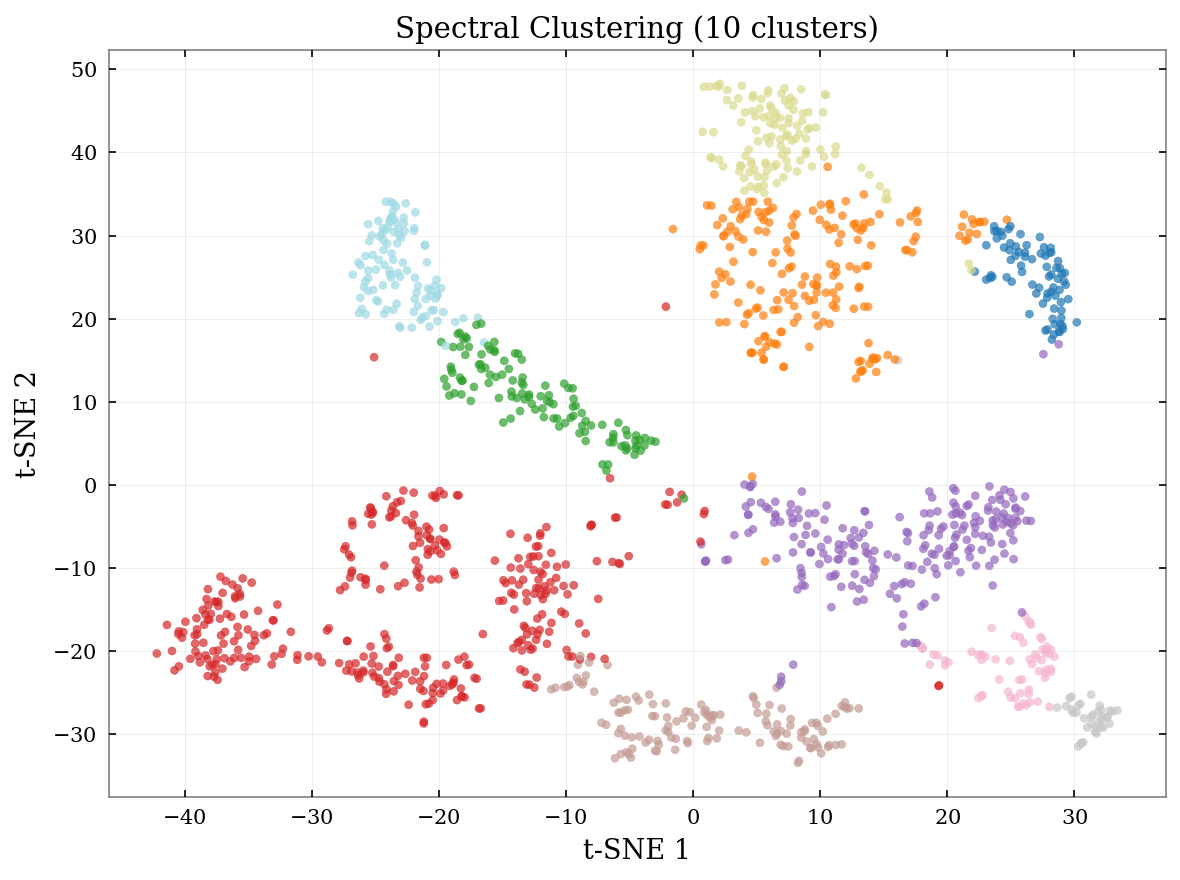

In [ ]:
# Spectral Clustering
n_clusters = 10  
spectral = SpectralClustering(
    n_clusters=n_clusters, 
    affinity='nearest_neighbors',
    n_neighbors=5, 
    random_state=42
)
y_spectral = spectral.fit_predict(latents2) 

tsne = TSNE(n_components=2, random_state=42)
latents_2d = tsne.fit_transform(latents2) 

fig, ax= plt.subplots(figsize=(8, 6))

ax.scatter(latents_2d[:, 0], latents_2d[:, 1], 
                c=y_spectral, cmap='tab20', s=15, alpha=0.7)
ax.set_title(f'Spectral Clustering ({n_clusters} clusters)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()



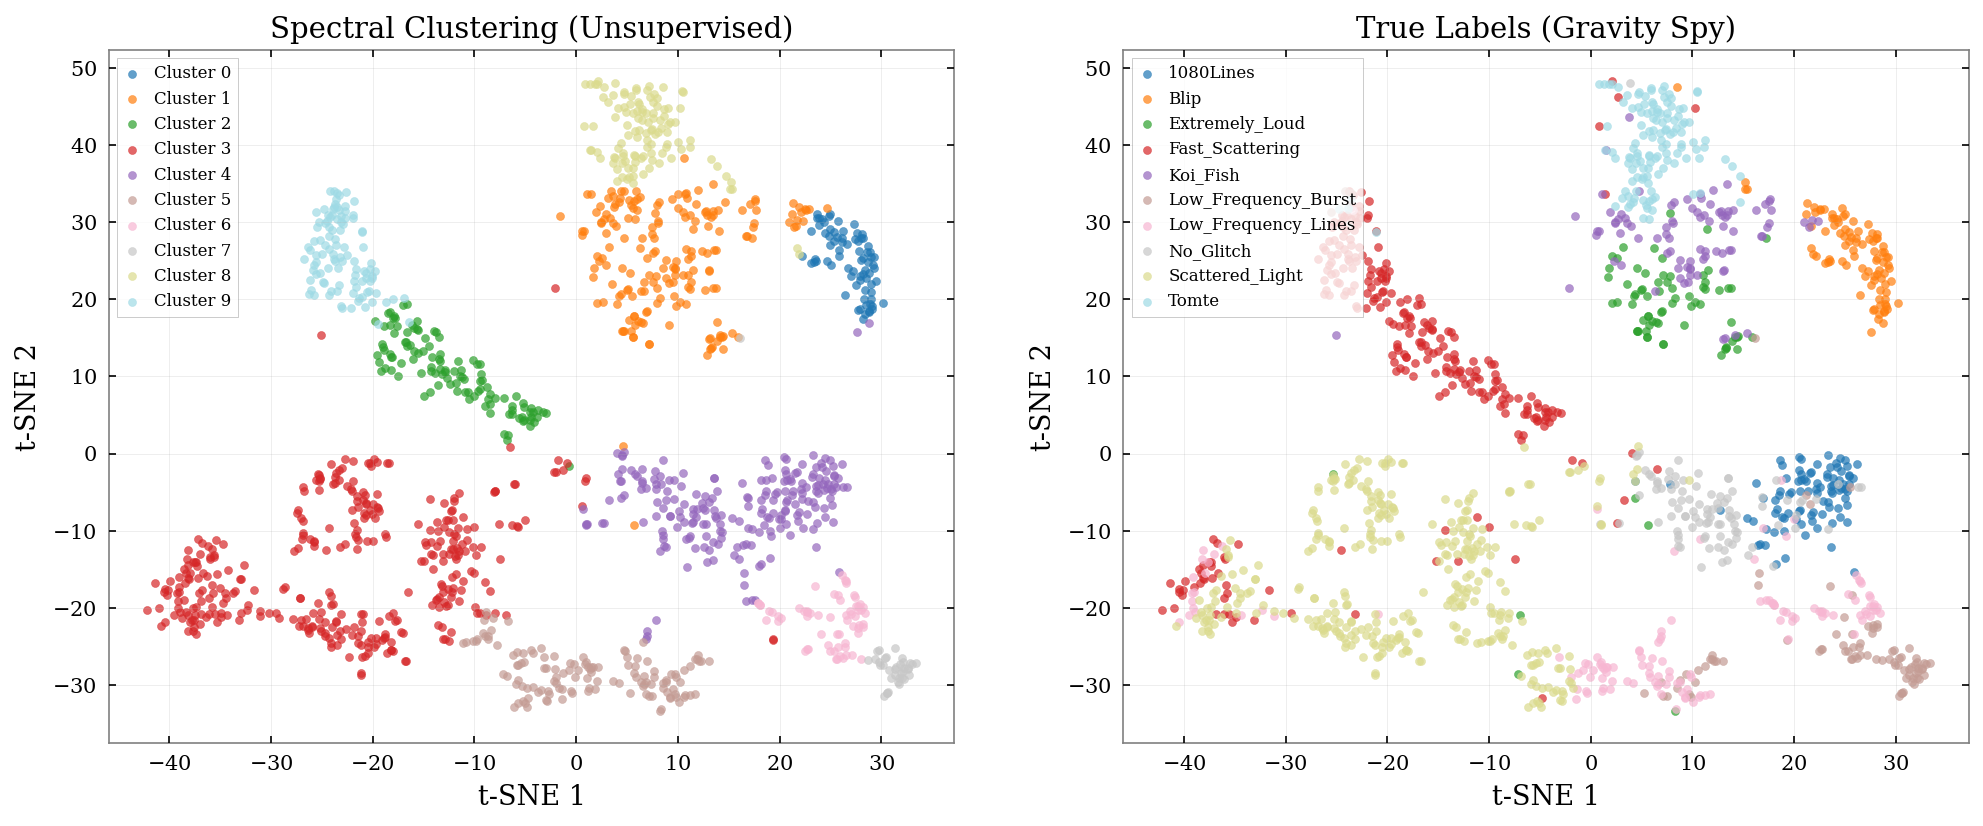

In [91]:
# Labeled test loader
test_dataset_labeled = GlitchDatasetWithLabels(test_filtered, img_folder="glitch_images_cropped_new")
test_loader_labeled = DataLoader(test_dataset_labeled, batch_size=32, shuffle=False)

# Extract true labels
true_labels = []
with torch.no_grad():
    for batch, labels in test_loader_labeled:
        true_labels.extend(labels)
le = LabelEncoder()
true_labels_encoded = le.fit_transform(true_labels)

unique_clusters = np.unique(y_spectral)
unique_labels = le.classes_
colors_cl = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))
colors_la = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Spectral clustering
for i, cluster in enumerate(unique_clusters):
    mask = y_spectral == cluster
    axes[0].scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                   c=[colors_cl[i]], label=f'Cluster {cluster}', s=15, alpha=0.7)
axes[0].set_title('Spectral Clustering (Unsupervised)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(loc='upper left', fontsize=8)


# True labels 
for i, label in enumerate(unique_labels):
    mask = true_labels_encoded == i
    axes[1].scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                   c=[colors_la[i]], label=label, s=15, alpha=0.7)

axes[1].set_title('True Labels (Gravity Spy)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(loc='upper left', fontsize=8)
plt.show()

In [99]:
ari = adjusted_rand_score(true_labels_encoded, y_spectral)
nmi = normalized_mutual_info_score(true_labels_encoded, y_spectral)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


Adjusted Rand Index (ARI): 0.5320
Normalized Mutual Information (NMI): 0.6667


Per-class purity
1080Lines: 100% in cluster C7
Blip: 82% in cluster C1
Extremely_Loud: 93% in cluster C4
Fast_Scattering: 43% in cluster C3
Koi_Fish: 96% in cluster C4
Low_Frequency_Burst: 41% in cluster C5
Low_Frequency_Lines: 45% in cluster C6
No_Glitch: 99% in cluster C7
Scattered_Light: 84% in cluster C8
Tomte: 78% in cluster C9


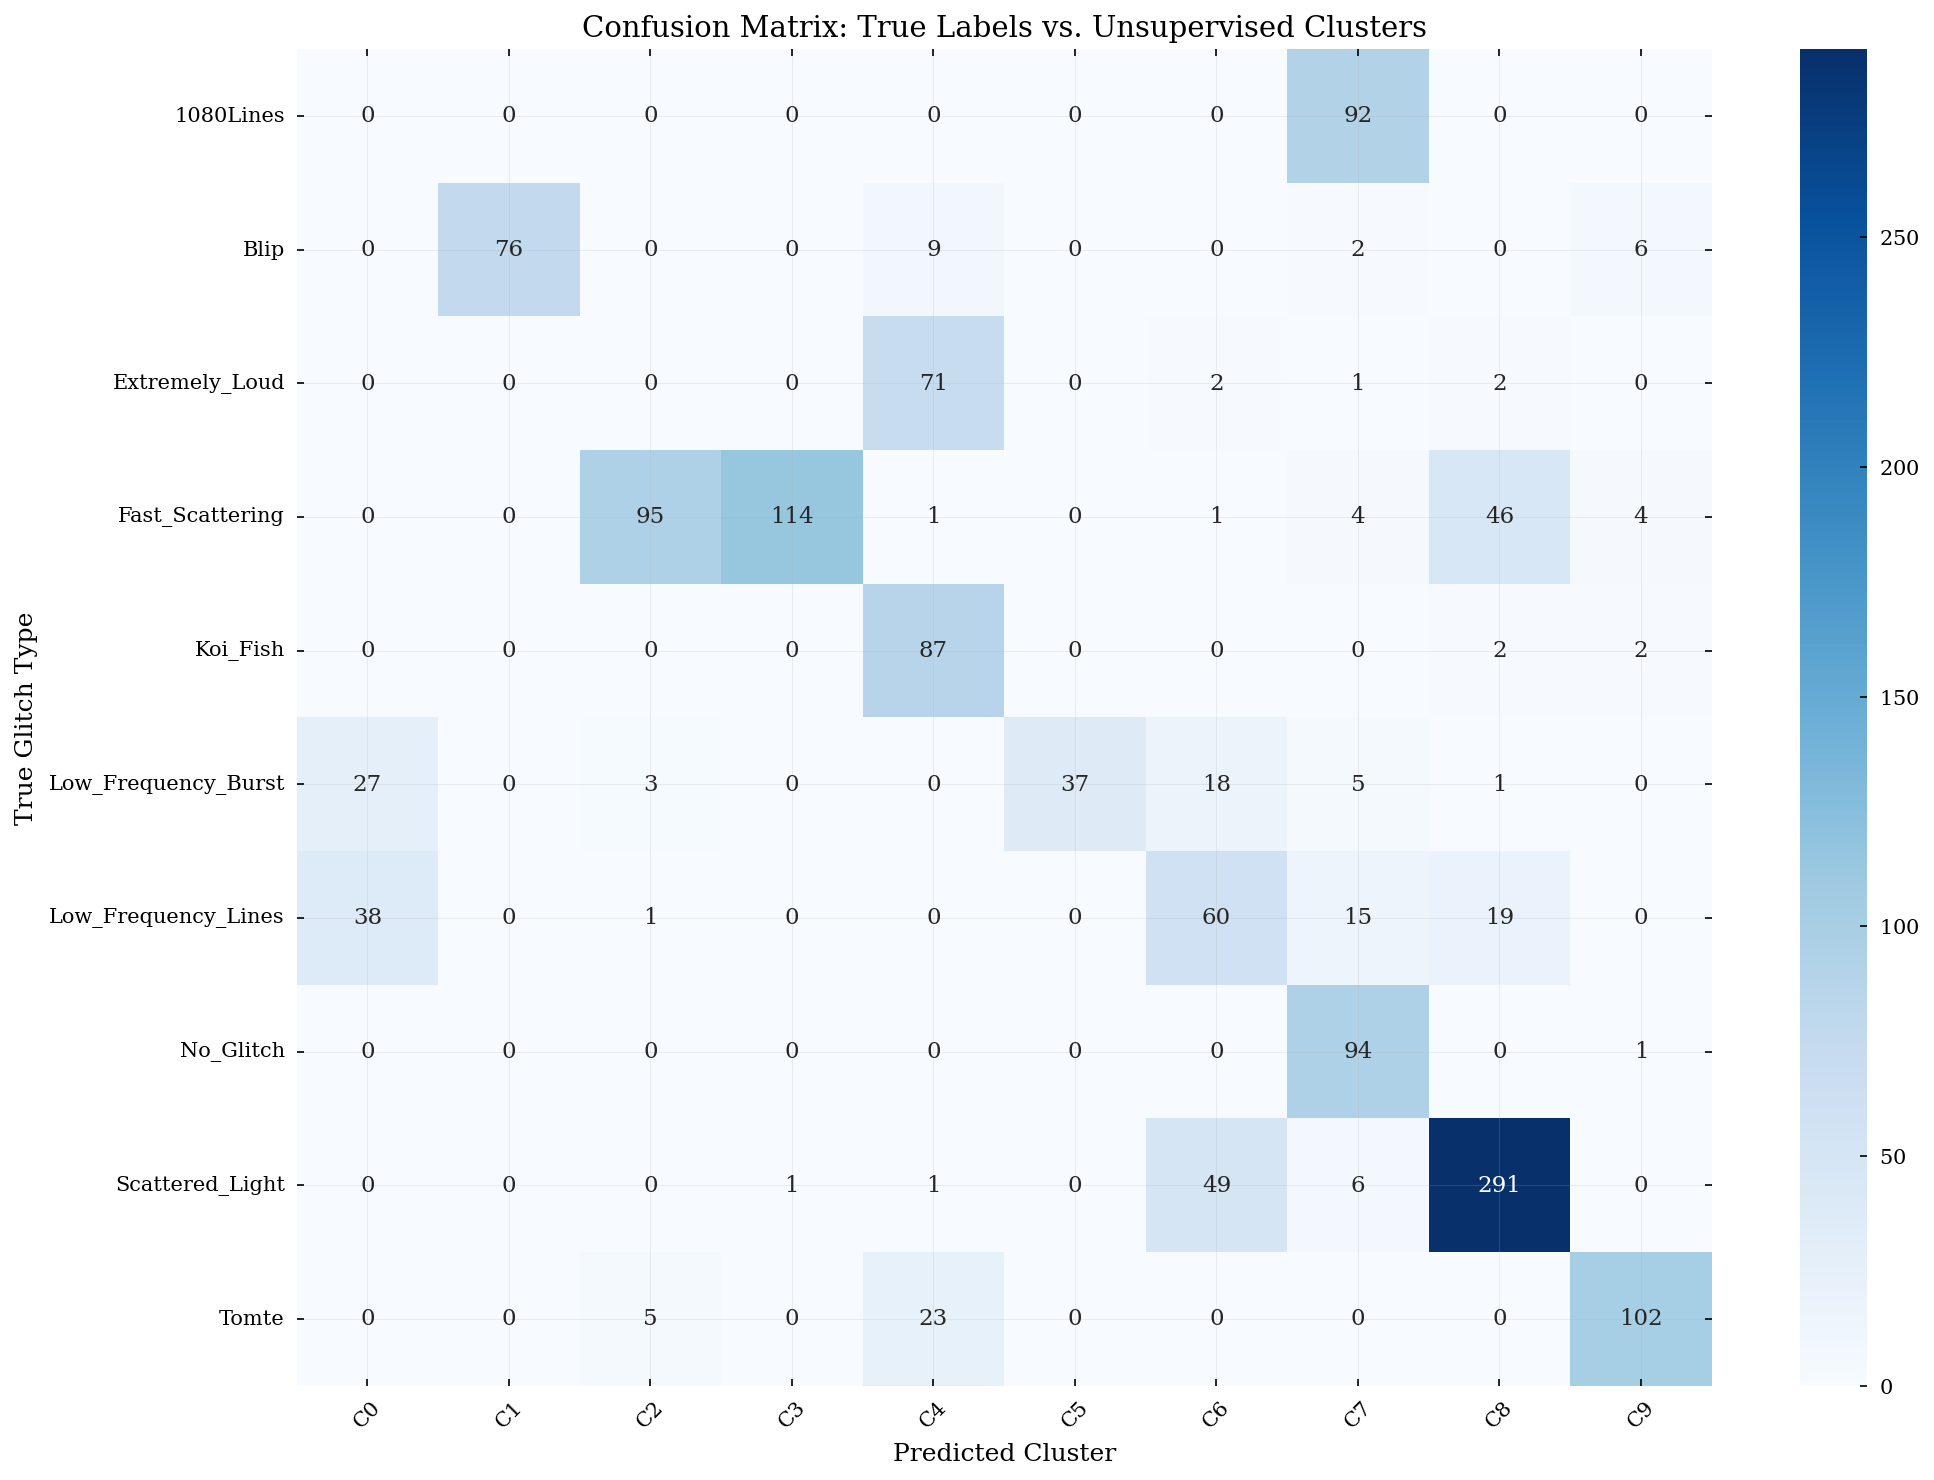

In [ ]:
y_spectral_reordered, cm_original, mapping = reorder_clusters(true_labels_encoded, y_spectral)
cm_reordered = confusion_matrix(true_labels_encoded, y_spectral_reordered)
unique_labels = list(le.classes_)
print("Per-class purity")
for i, label in enumerate(unique_labels):
    mask = true_labels_encoded == i
    if mask.sum() > 0:
        # Most common cluster
        main_cluster = np.bincount(y_spectral_reordered[mask]).argmax()
        percentage = (y_spectral_reordered[mask] == main_cluster).sum() / mask.sum() * 100
        print(f"{label}: {percentage:.0f}% in cluster C{main_cluster}")


plt.figure(figsize=(14, 10))
class_names = le.classes_

sns.heatmap(cm_reordered, 
            annot=True,    
            fmt='d', 
            cmap='Blues',   
            xticklabels=[f'C{i}' for i in range(len(np.unique(y_spectral_reordered)))],
            yticklabels=class_names)

plt.xlabel('Predicted Cluster', fontsize=12)
plt.ylabel('True Glitch Type', fontsize=12)
plt.title('Confusion Matrix: True Labels vs. Unsupervised Clusters', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()